# Compare Qiskit and PennyLane

We simulate the three-qubit ladder ansatz from the exercise. Each of its two layers applies $R_Y(\theta)$ to every qubit, followed by CNOTs $0\to1$ and $1\to2$. The reusable implementation and its assertions live in [`compare.py`](compare.py).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
from IPython.display import display
from qiskit.quantum_info import Statevector

from compare import (
    ANGLES, QISKIT_CIRCUIT, THETA, compare, pennylane_state, plot, qiskit_state
)
from compare import (
    architecture_data, benchmark, compare_own, plot_architectures, plot_rotations
)

## The same circuit in two frameworks

Qiskit represents a circuit as data in a `QuantumCircuit`; PennyLane represents it as a Python function wrapped in a QNode and attached to a device.

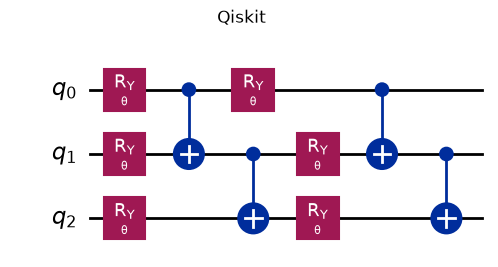

Matplotlib is building the font cache; this may take a moment.


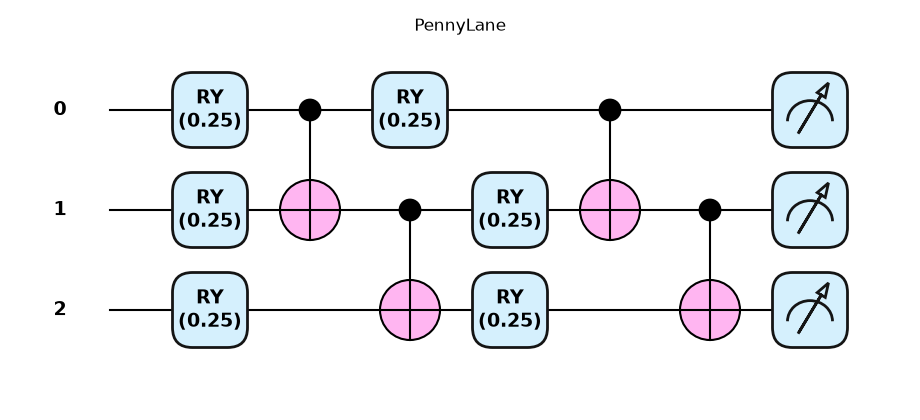

In [2]:
qiskit_figure = QISKIT_CIRCUIT.draw(output="mpl", fold=-1)
qiskit_figure.suptitle("Qiskit")
qiskit_figure.savefig("qiskit_circuit.png", dpi=150, bbox_inches="tight")
display(qiskit_figure)

pennylane_figure, _ = qml.draw_mpl(
    pennylane_state, decimals=2, style="pennylane"
)(0.25)
pennylane_figure.suptitle("PennyLane")
pennylane_figure.savefig("pennylane_circuit.png", dpi=150, bbox_inches="tight")
display(pennylane_figure)
plt.close("all")

## Statevector ordering

Qiskit's amplitude at an integer index is labelled $|q_2q_1q_0\rangle$: qubit 0 is the least-significant bit. PennyLane and our course simulator use wire order $|q_0q_1q_2\rangle$. Before comparing amplitudes, `qiskit_state` reshapes the Qiskit vector as a three-axis tensor, reverses its axes, and flattens it again. $P(000)$ and $\langle Z_1Z_2Z_3\rangle$ are unchanged by this reversal, but individual amplitude positions are not.

In [3]:
theta = 0.7
raw_qiskit = Statevector.from_instruction(
    QISKIT_CIRCUIT.assign_parameters({THETA: theta})
).data
ordered_qiskit = qiskit_state(theta)
state_pennylane = np.asarray(pennylane_state(theta))

print("Raw Qiskit equals PennyLane:    ", np.allclose(raw_qiskit, state_pennylane))
print("Reordered Qiskit equals PennyLane:", np.allclose(ordered_qiskit, state_pennylane))

Raw Qiskit equals PennyLane:     False
Reordered Qiskit equals PennyLane: True


## $P(000)$ and $\langle Z_1Z_2Z_3\rangle$

The script evaluates 201 angles from $0$ through $2\pi$, checks normalization, checks the known $\theta=0$ result, and requires both simulators to agree within $10^{-10}$.

Maximum difference: 4.441e-16
At theta=0: P(000)=1.0, <ZZZ>=1.0


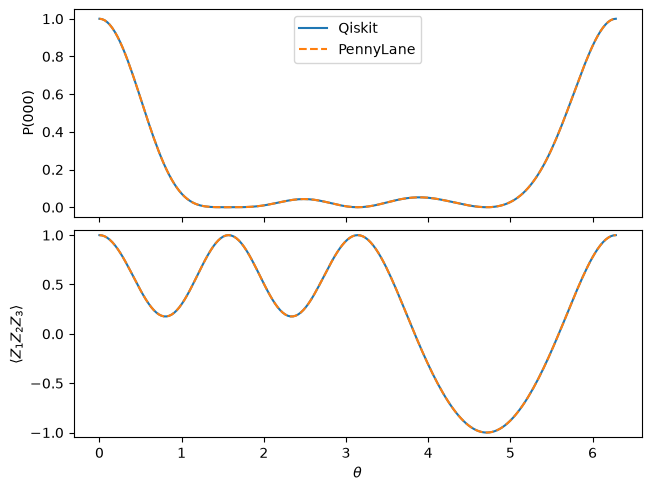

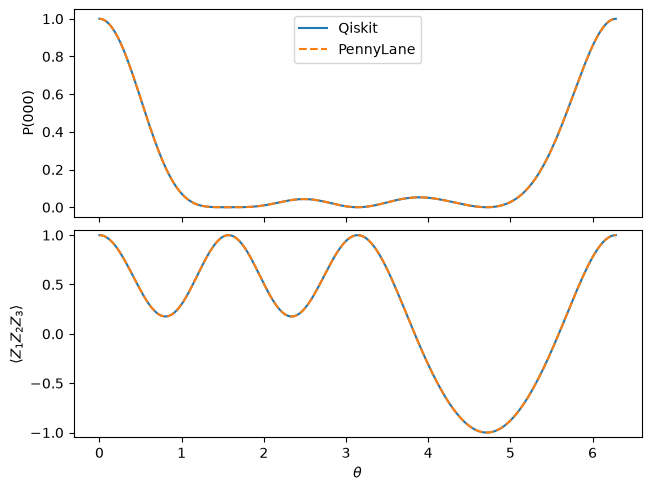

In [4]:
qiskit_values, pennylane_values = compare()
print(f"Maximum difference: {np.max(np.abs(qiskit_values - pennylane_values)):.3e}")
print(f"At theta=0: P(000)={qiskit_values[0, 0]:.1f}, <ZZZ>={qiskit_values[0, 1]:.1f}")
plot(qiskit_values, pennylane_values)

## Conclusion

The two simulators produce the same state and observables after accounting for Qiskit's bit ordering.

> Used Qiskit and PennyLane. Since I’m already familiar with both, implementing the circuit was pretty straightforward. They produced the same $P(000)$, and $\langle Z_1Z_2Z_3\rangle$ results across all tested values of theta. The only thing worth noting was Qiskit’s little-endian statevector ordering (Qiskit’s major-version migrations are a separate topic and worth noting as well, but they didn’t affect this exercise), after reordering the amplitudes, the full statevectors matched as well. Qiskit’s circuit-object approach and PennyLane’s QNode approach were both convenient, though imo, PennyLane was slightly more concise for this task.


## 8. Comparison with my NumPy simulator

The existing simulator accepts full-system matrices. A three-qubit $R_Y$ layer is therefore $R_Y \otimes R_Y \otimes R_Y$, while the two ladder gates are `CNOT ⊗ I` and `I ⊗ CNOT`.

In [5]:
own_values = compare_own()
print(f"Maximum NumPy/Qiskit difference: {np.max(np.abs(own_values - qiskit_values)):.3e}")

Maximum NumPy/Qiskit difference: 5.551e-16


## 9. Local timing comparison

The exact benchmark evaluates 201 statevectors after one warm-up and reports the median of five sweeps. The shot benchmark evaluates 60 angles with $2^{15}$ shots after one warm-up. These are local implementation timings, not general rankings of the frameworks.

In [6]:
benchmark_rows = benchmark()
print(f"{'Mode':<8} {'Framework':<12} {'Seconds':>9} {'Max P(000) error':>18}")
for row in benchmark_rows:
    print(
        f"{row['mode']:<8} {row['framework']:<12} "
        f"{row['seconds']:>9.4f} {row['max_p000_error']:>18.4f}"
    )

Mode     Framework      Seconds   Max P(000) error
exact    Qiskit          0.0252             0.0000
exact    PennyLane       0.0887             0.0000
shots    Qiskit          0.5714             0.0045
shots    PennyLane       0.0846             0.0064


## 10. Changing the architecture

First, vary the circuit from two to four qubits and from one to three layers. Then keep the original three-qubit, two-layer circuit and replace the RY block with RX or RZ rotations.

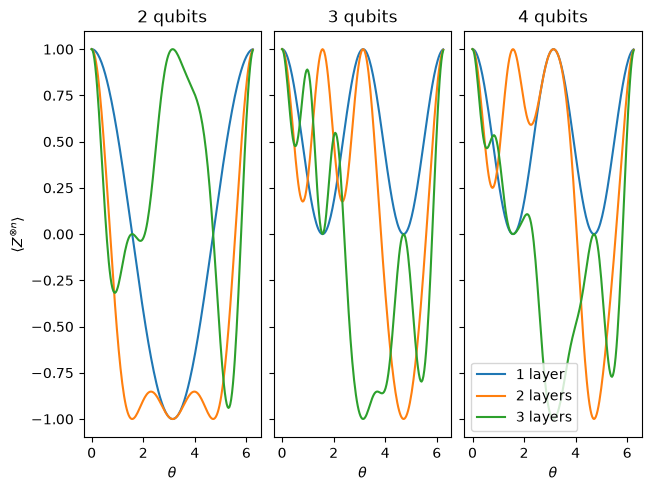

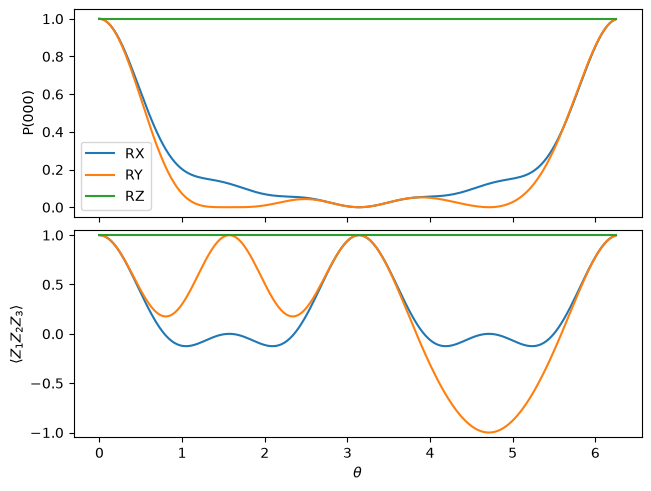

In [7]:
qubits_layers, rotations = architecture_data()

architecture_figure = plot_architectures(qubits_layers)
architecture_figure.savefig("qubits_layers.png", dpi=150)
display(architecture_figure)

rotation_figure = plot_rotations(rotations)
rotation_figure.savefig("rotation_gates.png", dpi=150)
display(rotation_figure)
plt.close("all")

More qubits and layers change the frequency and shape of the parity expectation. RX and RY produce non-trivial probability and parity curves. RZ remains flat at one because the initial $|000\rangle$ state only acquires phase, so the CNOT ladder never changes its populations.